# ASCON First-Round x′1 CPA/DPA Analysis — Clean 50,000-Trace Dataset

This notebook runs the **x′1 paper-style CPA/DPA attack** using the same clean first-round dataset used for x′0.

It will:
1. Load the dataset and run QC.
2. Run a quick x′1 screening test for `firmware` and `paper` bit-index modes.
3. Automatically select the better bit-index mode.
4. Run full x′1 CPA/DPA using 50,000 traces.
5. Save CSV results.
6. Optionally run robustness and shuffled-nonce sanity checks later.

In [1]:
import os, json, time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
print("Imports OK")

Imports OK


## 1. Paths

In [2]:
ASCON_ROOT = Path(r"C:\Users\thetp\Downloads\ASCON_FYP")

RUN_DIR = Path(r"C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\ascon_firstround_fixedkey_randomnonce_50000_gain28_samples12000_20260616_064747")

RESULTS_DIR = ASCON_ROOT / "04_Results" / "first_round_dpa" / "clean_50000_x1_cpa_dpa"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

META_PATH = RUN_DIR / "metadata.csv"
CONFIG_PATH = RUN_DIR / "config.json"
TRACE_NPY = RUN_DIR / "traces.npy"
TRACE_NPZ = RUN_DIR / "traces.npz"
TRACE_CACHE_NPY = RUN_DIR / "traces_cached_from_npz.npy"

assert RUN_DIR.exists(), f"RUN_DIR does not exist: {RUN_DIR}"
assert META_PATH.exists(), f"metadata.csv not found: {META_PATH}"
assert CONFIG_PATH.exists(), f"config.json not found: {CONFIG_PATH}"
assert TRACE_NPY.exists() or TRACE_NPZ.exists() or TRACE_CACHE_NPY.exists(), "No trace file found"

print("RUN_DIR:", RUN_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("traces.npy exists:", TRACE_NPY.exists())
print("traces.npz exists:", TRACE_NPZ.exists())
print("trace cache exists:", TRACE_CACHE_NPY.exists())

RUN_DIR: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\ascon_firstround_fixedkey_randomnonce_50000_gain28_samples12000_20260616_064747
RESULTS_DIR: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\clean_50000_x1_cpa_dpa
traces.npy exists: True
traces.npz exists: False
trace cache exists: False


## 2. Load dataset

In [3]:
metadata = pd.read_csv(META_PATH)
with open(CONFIG_PATH, "r") as f:
    config = json.load(f)

# Prefer memory-mappable .npy. If only .npz exists, create a cached .npy once.
if TRACE_NPY.exists():
    traces = np.load(TRACE_NPY, mmap_mode="r")
    trace_file_used = TRACE_NPY
elif TRACE_CACHE_NPY.exists():
    traces = np.load(TRACE_CACHE_NPY, mmap_mode="r")
    trace_file_used = TRACE_CACHE_NPY
else:
    print("Only traces.npz found. Creating traces_cached_from_npz.npy for memory-mapped analysis.")
    npz = np.load(TRACE_NPZ)
    print("NPZ keys:", npz.files)
    arr = npz[npz.files[0]]
    print("Loaded:", arr.shape, arr.dtype)
    if arr.dtype != np.float32:
        arr = arr.astype(np.float32)
    np.save(TRACE_CACHE_NPY, arr)
    del arr, npz
    gc.collect()
    traces = np.load(TRACE_CACHE_NPY, mmap_mode="r")
    trace_file_used = TRACE_CACHE_NPY

print("Trace file used:", trace_file_used)
print("traces shape:", traces.shape)
print("metadata shape:", metadata.shape)
print("fixed key:", metadata["key_hex"].iloc[0])
print("unique nonces:", metadata["nonce_hex"].nunique(), "/", len(metadata))
print("capture_ret counts:")
print(metadata["capture_ret"].value_counts(dropna=False))
print("trigger_count counts:")
print(metadata["trigger_count"].value_counts(dropna=False).head())
display(metadata.head())

Trace file used: C:\Users\thetp\Downloads\ASCON_FYP\03_Data\first_round_dpa\ascon_firstround_fixedkey_randomnonce_50000_gain28_samples12000_20260616_064747\traces.npy
traces shape: (50000, 12000)
metadata shape: (50000, 6)
fixed key: 00112233445566778899aabbccddeeff
unique nonces: 50000 / 50000
capture_ret counts:
capture_ret
False    50000
Name: count, dtype: int64
trigger_count counts:
trigger_count
10880    50000
Name: count, dtype: int64


,trace_index,key_hex,nonce_hex,response_hex,capture_ret,trigger_count
0,0,00112233445566778899aabbccddeeff,4324031e2fe9f839ac8b86c5cb693776,a7,False,10880
1,1,00112233445566778899aabbccddeeff,7e9dc2549cb45f8adc5332fb6c12a3ee,e2,False,10880
2,2,00112233445566778899aabbccddeeff,58440bf848bc1a19568928e2d8e227f4,9f,False,10880
3,3,00112233445566778899aabbccddeeff,a26ede44234af84d7cdd09dc50791c4a,03,False,10880
4,4,00112233445566778899aabbccddeeff,5bc8d1c1579c22e47c593fe7bcd9629d,e1,False,10880


## 3. Quick waveform QC

qc_traces_shape : (1000, 12000)
sample_min : -0.5
sample_max : 0.3212890625
overall_clipping_fraction : 0.0018289166666666666
median_clipping_per_trace : 0.0018333333333333333
max_clipping_per_trace : 0.0021666666666666666


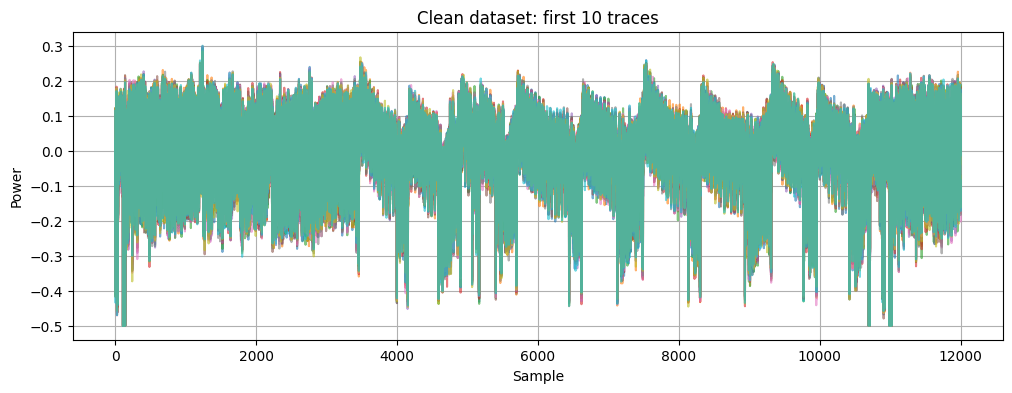

In [4]:
QC_N = min(1000, traces.shape[0])
qc_traces = np.asarray(traces[:QC_N], dtype=np.float32)
sat = ((qc_traces <= -0.49) | (qc_traces >= 0.49))
qc_info = {
    "qc_traces_shape": str(qc_traces.shape),
    "sample_min": float(qc_traces.min()),
    "sample_max": float(qc_traces.max()),
    "overall_clipping_fraction": float(sat.mean()),
    "median_clipping_per_trace": float(np.median(sat.mean(axis=1))),
    "max_clipping_per_trace": float(sat.mean(axis=1).max()),
}
for k, v in qc_info.items():
    print(k, ":", v)
with open(RESULTS_DIR / "dataset_qc_summary_x1.json", "w") as f:
    json.dump(qc_info, f, indent=4)

plt.figure(figsize=(12,4))
for i in range(10):
    plt.plot(qc_traces[i], alpha=0.6)
plt.title("Clean dataset: first 10 traces")
plt.xlabel("Sample")
plt.ylabel("Power")
plt.grid(True)
plt.show()

## 4. Settings

In [5]:
# First run: quick screen + full x1 analysis.
RUN_QUICK_SCREEN = False
RUN_FULL_X1 = False

# Optional later. Keep False first.
RUN_ROBUSTNESS = False
RUN_SHUFFLE_CHECK = True

QUICK_N_USE = 5000
QUICK_SAMPLE_START = 0
QUICK_SAMPLE_END = 12000
QUICK_SAMPLE_STRIDE = 2
QUICK_MODES_TO_TEST = ["firmware", "paper"]
QUICK_METHODS_TO_TEST = ["CPA", "DPA"]

FULL_N_USE = 50000
FULL_SAMPLE_START = 0
FULL_SAMPLE_END = 12000
FULL_SAMPLE_STRIDE = 1
FULL_METHODS_TO_TEST = ["CPA", "DPA"]

AUTO_SELECT_MODE = True
FULL_MODES_TO_TEST = ["firmware"]
BIT_POSITIONS = list(range(64))
CHUNK_SAMPLES = 1000

print("RUN_QUICK_SCREEN:", RUN_QUICK_SCREEN)
print("RUN_FULL_X1:", RUN_FULL_X1)
print("RUN_ROBUSTNESS:", RUN_ROBUSTNESS)
print("RUN_SHUFFLE_CHECK:", RUN_SHUFFLE_CHECK)

RUN_QUICK_SCREEN: False
RUN_FULL_X1: False
RUN_ROBUSTNESS: False
RUN_SHUFFLE_CHECK: True


## 5. x′1 model helpers

In [6]:
def load64_le_from_bytes(b, offset_bytes):
    x = 0
    for i in range(8):
        x |= int(b[offset_bytes + i]) << (8 * i)
    return x

def load64_le_from_hex(hexstr, offset_bytes):
    b = bytes.fromhex(hexstr)
    return load64_le_from_bytes(b, offset_bytes)

def bit_scalar(x, i):
    return (int(x) >> (i % 64)) & 1

def bits_from_uint64_array(arr, idx):
    return ((arr >> np.uint64(idx % 64)) & np.uint64(1)).astype(np.uint8)

def x1_indices(i, mode):
    """
    x′1 linear layer: x1 XOR ROR(x1,61) XOR ROR(x1,39).
    firmware mode uses direct ROR offsets for this C implementation.
    paper mode uses the paper's index convention: i, i+3, i+25.
    """
    if mode == "firmware":
        return [i, i + 61, i + 39]
    elif mode == "paper":
        return [i, i + 3, i + 25]
    else:
        raise ValueError("mode must be 'firmware' or 'paper'")

def true_x1_candidate(K0, K1, i, mode):
    # x′1 recovers x1 XOR x2 key-bit relationship.
    # The first ASCON round XORs RC=0xf0 into x2, so include it in the relation.
    relation = K0 ^ K1 ^ 0xF0
    idxs = x1_indices(i, mode)
    c0 = bit_scalar(relation, idxs[0])
    c1 = bit_scalar(relation, idxs[1])
    c2 = bit_scalar(relation, idxs[2])
    return c0 | (c1 << 1) | (c2 << 2)

def x1_predictions_all_candidates(N0, N1, i, mode):
    """
    x′1 selection function:
      S_i = m_i(k0+1) + m'_i
          + m_{i+r1}(k1+1) + m'_{i+r1}
          + m_{i+r2}(k2+1) + m'_{i+r2}
    where + is XOR over GF(2).
    """
    idxs = x1_indices(i, mode)
    m0  = bits_from_uint64_array(N0, idxs[0])
    mp0 = bits_from_uint64_array(N1, idxs[0])
    m1  = bits_from_uint64_array(N0, idxs[1])
    mp1 = bits_from_uint64_array(N1, idxs[1])
    m2  = bits_from_uint64_array(N0, idxs[2])
    mp2 = bits_from_uint64_array(N1, idxs[2])

    P = np.zeros((len(N0), 8), dtype=np.uint8)
    for cand in range(8):
        c0 = (cand >> 0) & 1
        c1 = (cand >> 1) & 1
        c2 = (cand >> 2) & 1
        pred = np.zeros(len(N0), dtype=np.uint8)
        pred ^= (m0 & (c0 ^ 1)) ^ mp0
        pred ^= (m1 & (c1 ^ 1)) ^ mp1
        pred ^= (m2 & (c2 ^ 1)) ^ mp2
        P[:, cand] = pred
    return P

fixed_key_hex = metadata["key_hex"].iloc[0]
fixed_key = bytes.fromhex(fixed_key_hex)
K0 = load64_le_from_bytes(fixed_key, 0)
K1 = load64_le_from_bytes(fixed_key, 8)
print("K0:", hex(K0))
print("K1:", hex(K1))
print("K0 XOR K1 XOR 0xf0:", hex(K0 ^ K1 ^ 0xF0))
for mode in ["firmware", "paper"]:
    print(mode, "true x1 candidate bit 0:", true_x1_candidate(K0, K1, 0, mode))

K0: 0x7766554433221100
K1: 0xffeeddccbbaa9988
K0 XOR K1 XOR 0xf0: 0x8888888888888878
firmware true x1 candidate bit 0: 4
paper true x1 candidate bit 0: 2


In [7]:
def prepare_nonce_words(metadata_df, shuffle_nonce=False, seed=12345):
    nonce_hex = metadata_df["nonce_hex"].astype(str).to_numpy().copy()
    if shuffle_nonce:
        rng = np.random.default_rng(seed)
        rng.shuffle(nonce_hex)
    N0 = np.array([load64_le_from_hex(nh, 0) for nh in nonce_hex], dtype=np.uint64)
    N1 = np.array([load64_le_from_hex(nh, 8) for nh in nonce_hex], dtype=np.uint64)
    return N0, N1

## 6. CPA/DPA scoring functions

In [8]:
def update_best(best_scores, best_samples, score_chunk, sample_indices_chunk):
    abs_scores = np.abs(score_chunk)
    local_argmax = np.argmax(abs_scores, axis=1)
    local_best = abs_scores[np.arange(abs_scores.shape[0]), local_argmax]
    better = local_best > best_scores
    best_scores[better] = local_best[better]
    best_samples[better] = sample_indices_chunk[local_argmax[better]]

def score_candidates_chunked(P, traces_obj, sample_indices, methods=("CPA", "DPA"), chunk_samples=1000):
    N, C = P.shape
    P_float = P.astype(np.float32)
    results = {}

    if "CPA" in methods:
        P_centered = P_float - P_float.mean(axis=0, keepdims=True)
        p_energy = np.sum(P_centered * P_centered, axis=0)
        cpa_best_scores = np.full(C, -np.inf, dtype=np.float64)
        cpa_best_samples = np.full(C, -1, dtype=np.int64)

    if "DPA" in methods:
        count1 = P_float.sum(axis=0)
        count0 = N - count1
        count1_safe = np.maximum(count1, 1)
        count0_safe = np.maximum(count0, 1)
        dpa_best_scores = np.full(C, -np.inf, dtype=np.float64)
        dpa_best_samples = np.full(C, -1, dtype=np.int64)

    for start in range(0, len(sample_indices), chunk_samples):
        idx_chunk = sample_indices[start:start + chunk_samples]
        T = np.asarray(traces_obj[:N, idx_chunk], dtype=np.float32)

        if "CPA" in methods:
            T_centered = T - T.mean(axis=0, keepdims=True)
            t_energy = np.sum(T_centered * T_centered, axis=0)
            numerator = P_centered.T @ T_centered
            denom = np.sqrt(p_energy[:, None] * t_energy[None, :]) + 1e-12
            corr = numerator / denom
            update_best(cpa_best_scores, cpa_best_samples, corr, idx_chunk)

        if "DPA" in methods:
            sum1 = P_float.T @ T
            total = T.sum(axis=0, keepdims=True)
            sum0 = total - sum1
            mean1 = sum1 / count1_safe[:, None]
            mean0 = sum0 / count0_safe[:, None]
            diff = mean1 - mean0
            update_best(dpa_best_scores, dpa_best_samples, diff, idx_chunk)

    if "CPA" in methods:
        results["CPA"] = {"scores": cpa_best_scores, "best_samples": cpa_best_samples}
    if "DPA" in methods:
        results["DPA"] = {"scores": dpa_best_scores, "best_samples": dpa_best_samples}
    return results

## 7. Run x′1 analysis

In [9]:
def run_x1_analysis(traces_obj, metadata_df, N_USE, sample_start=0, sample_end=None, sample_stride=1,
                    modes=("firmware",), methods=("CPA", "DPA"), bit_positions=range(64),
                    chunk_samples=1000, shuffle_nonce=False, shuffle_seed=12345, label="x1_analysis"):
    if sample_end is None:
        sample_end = traces_obj.shape[1]
    sample_indices = np.arange(sample_start, sample_end, sample_stride)
    metadata_use = metadata_df.iloc[:N_USE].copy().reset_index(drop=True)
    N0_use, N1_use = prepare_nonce_words(metadata_use, shuffle_nonce=shuffle_nonce, seed=shuffle_seed)
    rows = []
    t0 = time.time()

    for mode in modes:
        print("\nMode:", mode, "| shuffle_nonce:", shuffle_nonce)
        for bit_i in bit_positions:
            P = x1_predictions_all_candidates(N0_use, N1_use, bit_i, mode)
            true_cand = true_x1_candidate(K0, K1, bit_i, mode)
            score_result = score_candidates_chunked(P, traces_obj, sample_indices, methods=methods, chunk_samples=chunk_samples)
            for method in methods:
                scores = score_result[method]["scores"]
                best_samples = score_result[method]["best_samples"]
                order = np.argsort(scores)[::-1]
                true_rank = int(np.where(order == true_cand)[0][0]) + 1
                best_cand = int(order[0])
                rows.append({
                    "label": label, "target": "x1_prime", "mode": mode, "method": method,
                    "shuffle_nonce": bool(shuffle_nonce), "N_USE": int(N_USE),
                    "sample_start": int(sample_start), "sample_end": int(sample_end), "sample_stride": int(sample_stride),
                    "bit_i": int(bit_i), "true_candidate": int(true_cand), "best_candidate": int(best_cand),
                    "true_rank": int(true_rank), "best_score": float(scores[best_cand]), "true_score": float(scores[true_cand]),
                    "best_sample_original": int(best_samples[best_cand]),
                    "true_best_sample_original": int(best_samples[true_cand]),
                    "candidate_scores": scores.tolist()
                })
            if bit_i % 8 == 0:
                print(f"  bit {bit_i:02d} done | elapsed {time.time()-t0:.1f}s")
    return pd.DataFrame(rows)

def summarise_result(df):
    rows=[]
    for keys, g in df.groupby(["label", "mode", "method", "shuffle_nonce"]):
        label, mode, method, shuffle_nonce = keys
        rows.append({
            "label": label, "mode": mode, "method": method, "shuffle_nonce": shuffle_nonce,
            "N_USE": int(g["N_USE"].iloc[0]), "sample_start": int(g["sample_start"].iloc[0]),
            "sample_end": int(g["sample_end"].iloc[0]), "sample_stride": int(g["sample_stride"].iloc[0]),
            "rank1_count_out_of_64": int((g["true_rank"] == 1).sum()),
            "rank_le_2_out_of_64": int((g["true_rank"] <= 2).sum()),
            "rank_le_4_out_of_64": int((g["true_rank"] <= 4).sum()),
            "average_true_rank": float(g["true_rank"].mean()),
            "median_true_rank": float(g["true_rank"].median()),
            "max_true_rank": int(g["true_rank"].max()),
            "mean_best_score": float(g["best_score"].mean()),
            "mean_true_score": float(g["true_score"].mean())
        })
    return pd.DataFrame(rows)

print("Functions ready")

Functions ready


## 8. Quick screen

In [10]:
if RUN_QUICK_SCREEN:
    quick_results_df = run_x1_analysis(
        traces_obj=traces, metadata_df=metadata, N_USE=QUICK_N_USE,
        sample_start=QUICK_SAMPLE_START, sample_end=QUICK_SAMPLE_END, sample_stride=QUICK_SAMPLE_STRIDE,
        modes=QUICK_MODES_TO_TEST, methods=QUICK_METHODS_TO_TEST,
        bit_positions=BIT_POSITIONS, chunk_samples=CHUNK_SAMPLES,
        shuffle_nonce=False, label="quick_x1_screen")

    quick_summary_df = summarise_result(quick_results_df)
    display(quick_summary_df.sort_values(["rank1_count_out_of_64", "average_true_rank"], ascending=[False, True]))
    quick_results_df.to_csv(RESULTS_DIR / f"x1_quick_screen_results_N{QUICK_N_USE}_stride{QUICK_SAMPLE_STRIDE}.csv", index=False)
    quick_summary_df.to_csv(RESULTS_DIR / f"x1_quick_screen_summary_N{QUICK_N_USE}_stride{QUICK_SAMPLE_STRIDE}.csv", index=False)

    if AUTO_SELECT_MODE:
        best_row = quick_summary_df.sort_values(["rank1_count_out_of_64", "average_true_rank"], ascending=[False, True]).iloc[0]
        SELECTED_MODE = str(best_row["mode"])
        print("AUTO_SELECTED_MODE:", SELECTED_MODE)
        display(pd.DataFrame([best_row]))
    else:
        SELECTED_MODE = FULL_MODES_TO_TEST[0]
else:
    SELECTED_MODE = FULL_MODES_TO_TEST[0]

print("Selected mode for full run:", SELECTED_MODE)

Selected mode for full run: firmware


## 9. Full x′1 CPA/DPA

In [11]:
if RUN_FULL_X1:
    modes_for_full = [SELECTED_MODE] if AUTO_SELECT_MODE else FULL_MODES_TO_TEST
    full_results_df = run_x1_analysis(
        traces_obj=traces, metadata_df=metadata, N_USE=FULL_N_USE,
        sample_start=FULL_SAMPLE_START, sample_end=FULL_SAMPLE_END, sample_stride=FULL_SAMPLE_STRIDE,
        modes=modes_for_full, methods=FULL_METHODS_TO_TEST,
        bit_positions=BIT_POSITIONS, chunk_samples=CHUNK_SAMPLES,
        shuffle_nonce=False, label="clean_50000_x1")

    full_summary_df = summarise_result(full_results_df)
    display(full_summary_df)

    suffix = f"N{FULL_N_USE}_samples{FULL_SAMPLE_START}_{FULL_SAMPLE_END}_stride{FULL_SAMPLE_STRIDE}"
    results_csv = RESULTS_DIR / f"x1_clean_cpa_dpa_results_{suffix}.csv"
    summary_csv = RESULTS_DIR / f"x1_clean_cpa_dpa_summary_{suffix}.csv"
    full_results_df.to_csv(results_csv, index=False)
    full_summary_df.to_csv(summary_csv, index=False)
    print("Saved detailed results:", results_csv)
    print("Saved summary:", summary_csv)
else:
    print("Full x′1 run disabled.")

Full x′1 run disabled.


In [12]:
if RUN_FULL_X1:
    for mode in full_results_df["mode"].unique():
        for method in full_results_df["method"].unique():
            df = full_results_df[(full_results_df["mode"] == mode) & (full_results_df["method"] == method)].sort_values("bit_i")
            plt.figure(figsize=(12,4))
            plt.plot(df["bit_i"], df["true_rank"], marker="o")
            plt.axhline(4.5, linestyle="--", label="random average rank ≈ 4.5")
            plt.title(f"Clean dataset x′1 {method} true rank per bit ({mode} mode)")
            plt.xlabel("Bit position i")
            plt.ylabel("True candidate rank, 1 is best")
            plt.yticks(range(1,9))
            plt.grid(True)
            plt.legend()
            plt.show()

## 10. Optional robustness test

In [13]:
TRACE_COUNTS = [500, 1000, 2000, 5000, 10000, 20000, 30000, 50000]
ROBUSTNESS_SAMPLE_STRIDE = 2
ROBUSTNESS_MODES = [SELECTED_MODE]
ROBUSTNESS_METHODS = ["CPA", "DPA"]

if not RUN_ROBUSTNESS:
    print("Robustness test disabled. Set RUN_ROBUSTNESS = True after full x′1 works.")
else:
    robustness_all=[]
    for n in TRACE_COUNTS:
        print("\n" + "="*80)
        print("Running x′1 robustness N =", n)
        df_n = run_x1_analysis(traces, metadata, n, 0, traces.shape[1], ROBUSTNESS_SAMPLE_STRIDE,
                               ROBUSTNESS_MODES, ROBUSTNESS_METHODS, BIT_POSITIONS,
                               CHUNK_SAMPLES, False, label=f"robustness_x1_N{n}")
        robustness_all.append(df_n)
    robustness_df = pd.concat(robustness_all, ignore_index=True)
    robustness_summary_df = summarise_result(robustness_df).sort_values(["method", "N_USE"])
    display(robustness_summary_df)
    robustness_df.to_csv(RESULTS_DIR / f"x1_trace_count_robustness_results_stride{ROBUSTNESS_SAMPLE_STRIDE}.csv", index=False)
    robustness_summary_df.to_csv(RESULTS_DIR / f"x1_trace_count_robustness_summary_stride{ROBUSTNESS_SAMPLE_STRIDE}.csv", index=False)

Robustness test disabled. Set RUN_ROBUSTNESS = True after full x′1 works.


## 11. Optional shuffled-nonce sanity check

In [14]:
SHUFFLE_N_USE = 50000
SHUFFLE_SAMPLE_STRIDE = 1
SHUFFLE_MODES = [SELECTED_MODE]
SHUFFLE_METHODS = ["CPA", "DPA"]
SHUFFLE_SEED = 20260617

if not RUN_SHUFFLE_CHECK:
    print("Shuffle sanity check disabled. Set RUN_SHUFFLE_CHECK = True after full x′1 works.")
else:
    shuffle_df = run_x1_analysis(traces, metadata, SHUFFLE_N_USE, 0, traces.shape[1], SHUFFLE_SAMPLE_STRIDE,
                                 SHUFFLE_MODES, SHUFFLE_METHODS, BIT_POSITIONS,
                                 CHUNK_SAMPLES, True, SHUFFLE_SEED, label=f"shuffle_x1_N{SHUFFLE_N_USE}")
    shuffle_summary_df = summarise_result(shuffle_df)
    display(shuffle_summary_df)
    shuffle_df.to_csv(RESULTS_DIR / f"x1_shuffle_sanity_results_N{SHUFFLE_N_USE}.csv", index=False)
    shuffle_summary_df.to_csv(RESULTS_DIR / f"x1_shuffle_sanity_summary_N{SHUFFLE_N_USE}.csv", index=False)


Mode: firmware | shuffle_nonce: True
  bit 00 done | elapsed 5.7s
  bit 08 done | elapsed 45.2s
  bit 16 done | elapsed 84.7s
  bit 24 done | elapsed 124.3s
  bit 32 done | elapsed 163.8s
  bit 40 done | elapsed 203.5s
  bit 48 done | elapsed 243.0s
  bit 56 done | elapsed 282.6s


,label,mode,method,shuffle_nonce,N_USE,sample_start,sample_end,sample_stride,rank1_count_out_of_64,rank_le_2_out_of_64,rank_le_4_out_of_64,average_true_rank,median_true_rank,max_true_rank,mean_best_score,mean_true_score
0,shuffle_x1_N50000,firmware,CPA,True,50000,0,12000,1,9,22,42,3.6875,4.0,8,0.020057,0.017850
1,shuffle_x1_N50000,firmware,DPA,True,50000,0,12000,1,11,16,38,4.1250,4.0,8,0.000758,0.000597


## Figure 1 — x′1 true-rank per bit position

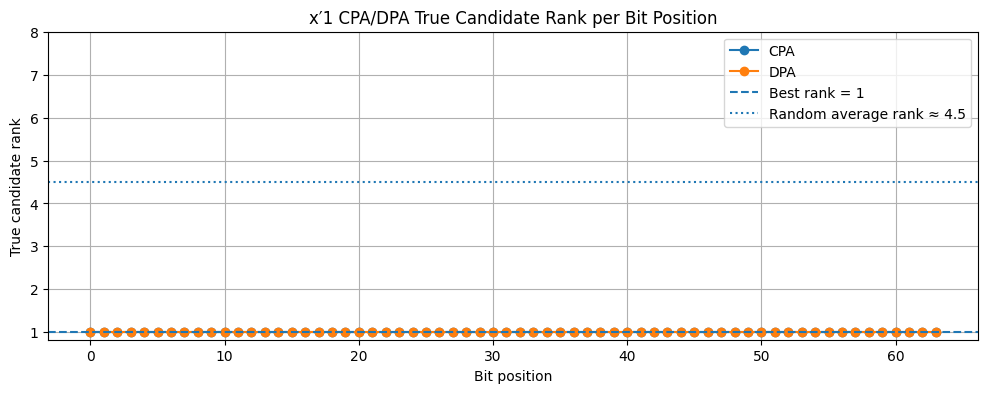

Saved: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\clean_50000_x1_cpa_dpa\figures\fig1_x1_true_rank_per_bit.png
Saved: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\clean_50000_x1_cpa_dpa\figures\fig1_x1_true_rank_per_bit.pdf


In [15]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ASCON_ROOT = Path(r"C:\Users\thetp\Downloads\ASCON_FYP")

RESULTS_DIR = ASCON_ROOT / "04_Results" / "first_round_dpa" / "clean_50000_x1_cpa_dpa"
FIG_DIR = RESULTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

full_path = RESULTS_DIR / "x1_clean_cpa_dpa_results_N50000_samples0_12000_stride1.csv"
full = pd.read_csv(full_path)

plt.figure(figsize=(12, 4))

for method in ["CPA", "DPA"]:
    df = full[full["method"] == method].sort_values("bit_i")
    plt.plot(df["bit_i"], df["true_rank"], marker="o", label=method)

plt.axhline(1, linestyle="--", label="Best rank = 1")
plt.axhline(4.5, linestyle=":", label="Random average rank ≈ 4.5")

plt.title("x′1 CPA/DPA True Candidate Rank per Bit Position")
plt.xlabel("Bit position")
plt.ylabel("True candidate rank")
plt.yticks(range(1, 9))
plt.grid(True)
plt.legend()

out_png = FIG_DIR / "fig1_x1_true_rank_per_bit.png"
out_pdf = FIG_DIR / "fig1_x1_true_rank_per_bit.pdf"

plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
plt.show()

print("Saved:", out_png)
print("Saved:", out_pdf)

## Figure 2 — x′1 trace-count robustness

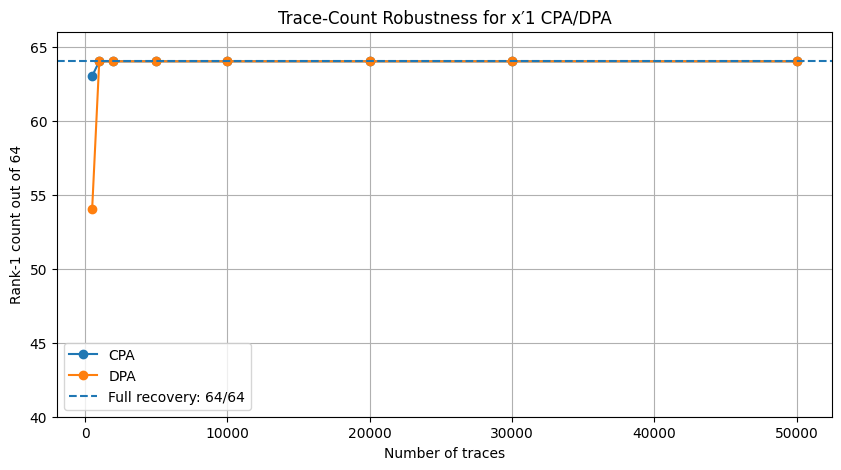

Saved: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\clean_50000_x1_cpa_dpa\figures\fig2_x1_trace_count_robustness.png
Saved: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\clean_50000_x1_cpa_dpa\figures\fig2_x1_trace_count_robustness.pdf


In [16]:
robust_path = RESULTS_DIR / "x1_trace_count_robustness_summary_stride2.csv"
robust = pd.read_csv(robust_path)

plt.figure(figsize=(10, 5))

for method in ["CPA", "DPA"]:
    df = robust[robust["method"] == method].sort_values("N_USE")
    plt.plot(
        df["N_USE"],
        df["rank1_count_out_of_64"],
        marker="o",
        label=method
    )

plt.axhline(64, linestyle="--", label="Full recovery: 64/64")

plt.title("Trace-Count Robustness for x′1 CPA/DPA")
plt.xlabel("Number of traces")
plt.ylabel("Rank-1 count out of 64")
plt.ylim(40, 66)
plt.grid(True)
plt.legend()

out_png = FIG_DIR / "fig2_x1_trace_count_robustness.png"
out_pdf = FIG_DIR / "fig2_x1_trace_count_robustness.pdf"

plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
plt.show()

print("Saved:", out_png)
print("Saved:", out_pdf)

## Figure 3 — x′1 normal vs shuffled-nonce sanity check

,method,rank1_count_out_of_64,average_true_rank,test
0,CPA,64,1.0000,Normal
1,DPA,64,1.0000,Normal
2,CPA,9,3.6875,Shuffled nonce
3,DPA,11,4.1250,Shuffled nonce


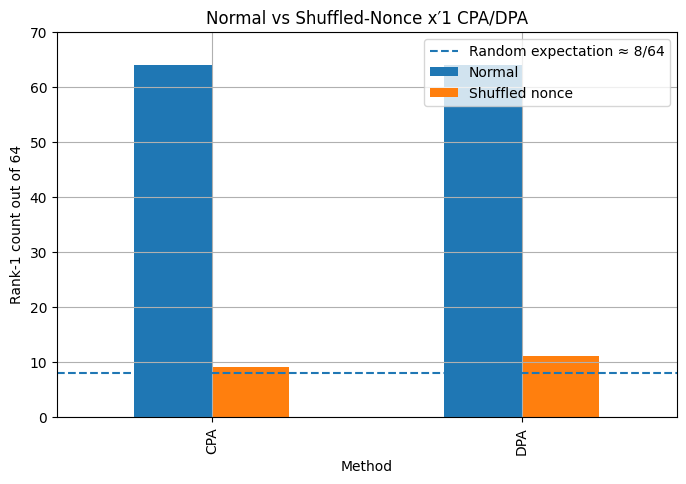

Saved: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\clean_50000_x1_cpa_dpa\figures\fig3_x1_normal_vs_shuffle.png
Saved: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\clean_50000_x1_cpa_dpa\figures\fig3_x1_normal_vs_shuffle.pdf
Saved table: C:\Users\thetp\Downloads\ASCON_FYP\04_Results\first_round_dpa\clean_50000_x1_cpa_dpa\figures\x1_normal_vs_shuffle_table.csv


In [17]:
normal_path = RESULTS_DIR / "x1_clean_cpa_dpa_summary_N50000_samples0_12000_stride1.csv"
shuffle_path = RESULTS_DIR / "x1_shuffle_sanity_summary_N50000.csv"

normal = pd.read_csv(normal_path)
shuffle = pd.read_csv(shuffle_path)

normal_small = normal[["method", "rank1_count_out_of_64", "average_true_rank"]].copy()
normal_small["test"] = "Normal"

shuffle_small = shuffle[["method", "rank1_count_out_of_64", "average_true_rank"]].copy()
shuffle_small["test"] = "Shuffled nonce"

compare = pd.concat([normal_small, shuffle_small], ignore_index=True)

display(compare)

compare_csv = FIG_DIR / "x1_normal_vs_shuffle_table.csv"
compare.to_csv(compare_csv, index=False)

plot_df = compare.pivot(index="method", columns="test", values="rank1_count_out_of_64")

ax = plot_df.plot(kind="bar", figsize=(8, 5))

ax.set_title("Normal vs Shuffled-Nonce x′1 CPA/DPA")
ax.set_xlabel("Method")
ax.set_ylabel("Rank-1 count out of 64")
ax.set_ylim(0, 70)
ax.axhline(8, linestyle="--", label="Random expectation ≈ 8/64")
ax.grid(True)
ax.legend()

fig = ax.get_figure()

out_png = FIG_DIR / "fig3_x1_normal_vs_shuffle.png"
out_pdf = FIG_DIR / "fig3_x1_normal_vs_shuffle.pdf"

fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")
plt.show()

print("Saved:", out_png)
print("Saved:", out_pdf)
print("Saved table:", compare_csv)

## Interpretation guide

For x′1 there are **8 candidates** per bit position.

Random expectation:
```text
Rank-1 count ≈ 8 / 64
Average true rank ≈ 4.5
```

Important wording:
```text
x′1 candidate recovery does not directly mean full key recovery.
x′1 recovers the x1⊕x2 key-bit relationship.
Combined with x′0, it can support key-bit reconstruction or key-space reduction.
```